In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import qutip
import scqubits
from scipy.optimize import minimize
from scipy.integrate import quad
from time import time
from tqdm import tqdm
from datetime import datetime

In [2]:
# Parameters
twopi = 2 * np.pi
anharmonicity = -0.3075 * twopi   # GHz
omega_d = 4.6040 * twopi          # Driving frequency in GHz
N = 8                     # Number of levels in the transmon
# gamma = 0.05            # Dissipation rate
T_lmsz = 400 * 2/9                    # Pulse duration
T_aeh = 800 * 2/9                    # Pulse duration
T_haeh = 800 * 2/9                    # Pulse duration
T1 = 0 * 2/9
beta = 0.03
tau = 127.33 * 2/9
sigma_lmsz = 127.33 * 2/9
sigma_aeh = 80 * 2/9
sigma_haeh = 160 * 2/9
D0 = 0.012
P = 10
# Operators
a = qutip.destroy(N)
# H0 = omega_d * (a.dag() * a + 0.5 * qeye(N)) + anharmonicity * a.dag()**2 * a**2


In [3]:
def lmsz_pulse(t, args):
    """
    LMSZ pulse shape: Const pulse with derivative
    """
    sigma = args['sigma']
    A = args['A']
    delta = args['delta']
    T = args['T']

    return A * np.heaviside(t, 0) * np.heaviside(T - t, 0)
    
def lmsz_delta(t, args):
    """
    LMSZ detuning shape: Linear detuning
    """
    sigma = args['sigma']
    A = args['A']
    delta = args['delta']
    T = args['T']
    d = args['d']
    _T1 = args['T1']
    _D0 = args['D0']

    return (d * ((t - T/2 - _T1) / sigma) + _D0) * np.heaviside(t, 0) * np.heaviside(T - t, 0) 
    
def aeh_pulse(t, args):
    """
    AEH pulse shape: Sech pulse with derivative
    """
    sigma = args['sigma']
    A = args['A']
    delta = args['delta']
    T = args['T']
    def _sech(t, T, sigma):
        return 1 / np.cosh((t - T/2) / sigma)
    return A * np.heaviside(t, 0) * np.heaviside(T - t, 0) * _sech(t, T, sigma)
    
def aeh_delta(t, args):
    """
    AEH detuning shape: Tanh shape
    """
    sigma = args['sigma']
    A = args['A']
    delta = args['delta']
    T = args['T']
    d = args['d']
    _T1 = args['T1']
    _D0 = args['D0']

    return (d * np.tanh((t - T/2 - _T1) / sigma) + _D0) * np.heaviside(t, 0) * np.heaviside(T - t, 0)

def haeh_pulse(t, args):
    """
    hAEH pulse shape: Sech pulse with derivative terminated midway
    """
    sigma = args['sigma']
    A = args['A']
    delta = args['delta']
    T = args['T']

    return A * np.heaviside(t, 0) * np.heaviside(T - t, 0) / np.cosh((t - T) / sigma)
    
def haeh_delta(t, args):
    """
    hAEH detuning shape: Tanh shape terminated midway
    """
    sigma = args['sigma']
    A = args['A']
    delta = args['delta']
    T = args['T']
    d = args['d']
    _T1 = args['T1']
    _D0 = args['D0']

    return (d * np.tanh((t - T - _T1) / sigma) + D0) * np.heaviside(t, 0) * np.heaviside(T - t, 0)

In [4]:
def hamiltonian_drive(pulse_func, delta_func, args):
    """
    Construct the time-dependent Hamiltonian for the given pulse shape
    """
    transmon = scqubits.Transmon(
    EJ=71.10953541,  
    EC=1.65550678,
    ng=0,
    ncut=31,
    truncated_dim=8)
    
    H0 = np.insert(np.diff(np.diag(transmon.hamiltonian(True))) - omega_d, 0, [0])
    H0 = np.diag(H0)
    #     H0 += np.diag(np.ones(8) * args["d"])
    
    
    H1 = transmon.n_operator(True)
    H1 /= np.abs(H1[0,1])
    H1 /= 2

    H2 = np.diag(np.ones(8))
    # H2 = np.diag(np.arange(8))
    H2[0,0] = 0
    
    H = [qutip.Qobj(H0), [qutip.Qobj(H1), pulse_func], [qutip.Qobj(H2), delta_func]]
    return H


def run_simulation(
    pulse_func, delta_func, 
    tlist, sigma, T, _T1,
    d_min, d_max, d_num,
    A_min, A_max, A_num,
    _D0
):
    """
    Run the time evolution simulation for the given pulse function and parameters
    """
    
    options = {
        # 'max_step': 1e-11,        # Maximum step size (much smaller than your ns timescale)
        'nsteps': 1000,          # Increase max number of integration steps
        # 'atol': 1e-12,            # Absolute tolerance (tighter)
        # 'rtol': 1e-10,            # Relative tolerance (tighter)
        # 'method': 'dop853'        # High-order Runge-Kutta method for accuracy
    }
    psi0 = qutip.basis(N, 0) * qutip.basis(N, 0).dag()  # initial state: ground state
    # result = mesolve(H, psi0, tlist, [], [basis(N, i) * basis(N, i).dag() for i in range(N)], args=pulse_args)
    d_range = np.linspace(d_min, d_max, d_num)
    A_range = np.linspace(A_min, A_max, A_num)
    tr_probs = []

    # Loop with progress bar
    # for i in tqdm(range(d_num), desc="Driving system with Hamiltonian", unit="iteration", ncols=100, ascii=True, colour='green'):
    for n_d, d in enumerate(d_range):
        values = []
        # t0 = time()
        for n_A, A in enumerate(A_range):
            pulse_args = {'sigma': sigma, 'A': A, 't0': T / 2, 'delta': 1 / (anharmonicity), 'd': d, 'T': T, 'T1': _T1, 'N': N, 'beta': beta, 'tau': tau, 'P': P, 'D0': _D0}
            H = hamiltonian_drive(pulse_func, delta_func, pulse_args)
            output = qutip.mesolve(
                H, psi0,
                args=pulse_args,
                tlist=tlist,
                options=options
            )
            values.append(output.states[-1])
        tr_probs.append(values)

    return tr_probs

In [5]:
def calculate_areas(_T1):
    def pa(sigma, T, _T1, _D0):
        return {'sigma': sigma, 'A': 1, 't0': T / 2, 'delta': 1 / (anharmonicity), 'd': 0, 'T': T, 'Т1': _T1, 'N': N, 'beta': beta, 'tau': tau, 'P': P, 'D0': D0}
    lmsz_area = quad(lambda t: lmsz_pulse(t, pa(sigma_lmsz, T_lmsz, _T1, D0)), 0, T_lmsz, limit=1000)
    aeh_area = quad(lambda t: aeh_pulse(t, pa(sigma_aeh, T_aeh, _T1, D0)), 0, T_aeh, limit=1000)
    haeh_area = quad(lambda t: haeh_pulse(t, pa(sigma_haeh, T_haeh, _T1, D0)), 0, T_haeh, limit=1000)
    return lmsz_area, aeh_area, haeh_area

lmsz, aeh, haeh = calculate_areas(T1)
lmsz_area, lmsz_area_err = lmsz
aeh_area, aeh_area_err = aeh
haeh_area, haeh_area_err = haeh
A_lmsz_max = 11.2 * np.pi / lmsz_area
A_aeh_max = 11.2 * np.pi / aeh_area
A_haeh_max = 10.2 * np.pi / haeh_area
# A_haeh_max = 0.57
A_lmsz_max, A_aeh_max, A_haeh_max

(0.39584067435231396, 0.635451468723366, 0.5787147304444941)

In [6]:
# Simulation parameters
tlist_lmsz = np.linspace(0, T_lmsz, 50)  # Time grid
tlist_aeh = np.linspace(0, T_aeh, 50)  # Time grid
tlist_haeh = np.linspace(0, T_haeh, 50)  # Time grid
d_num = 81
A_min, A_num = (0, 81)
d_lmsz_max, d_aeh_max, d_haeh_max = (0.6, .25, .1)

# Run simulations
result_lmsz = run_simulation(lmsz_pulse, lmsz_delta, tlist_lmsz, sigma_lmsz, T_lmsz, T1, -d_lmsz_max, d_lmsz_max, d_num, A_min, A_lmsz_max, A_num, D0)
result_aeh = run_simulation(aeh_pulse, aeh_delta, tlist_aeh, sigma_aeh, T_aeh, T1, -d_aeh_max, d_aeh_max, d_num, A_min, A_aeh_max, A_num, D0)
result_haeh = run_simulation(haeh_pulse, haeh_delta, tlist_haeh, sigma_haeh, T_haeh, T1, -d_haeh_max, d_haeh_max, d_num, A_min, A_haeh_max, A_num, D0)

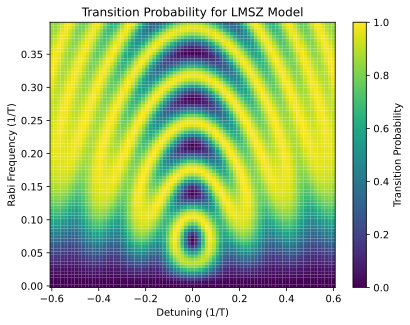

In [7]:
d_range = np.linspace(-d_lmsz_max, d_lmsz_max, d_num)
A_lmsz_range = np.linspace(A_min, A_lmsz_max, A_num)
tr_probs_lmsz = np.array([[np.abs(r[1,1]) for r in res] for res in result_lmsz])[::-1]

# Create pcolormesh plot
fig, ax = plt.subplots(1,1)
cmap = matplotlib.colormaps["viridis"]  # Choose a colormap
im = ax.pcolormesh(d_range, A_lmsz_range, tr_probs_lmsz.T, vmin=0, vmax=1, cmap=cmap)
fig.colorbar(im, ax=ax, label='Transition Probability')
plt.ylabel('Rabi Frequency (1/T)')
plt.xlabel('Detuning (1/T)')
plt.title('Transition Probability for LMSZ Model')
plt.show()

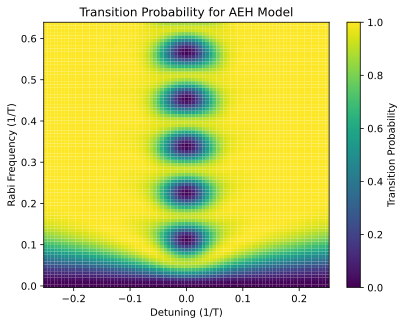

In [8]:
d_range = np.linspace(-d_aeh_max, d_aeh_max, d_num)
A_aeh_range = np.linspace(A_min, A_aeh_max, A_num)
tr_probs_aeh = np.array([[np.abs(r[1,1]) for r in res] for res in result_aeh])[::-1]

# Create pcolormesh plot
fig, ax = plt.subplots(1,1)
cmap = matplotlib.colormaps["viridis"]  # Choose a colormap
im = ax.pcolormesh(d_range, A_aeh_range, tr_probs_aeh.T, vmin=0, vmax=1, cmap=cmap)
fig.colorbar(im, ax=ax, label='Transition Probability')
plt.ylabel('Rabi Frequency (1/T)')
plt.xlabel('Detuning (1/T)')
plt.title('Transition Probability for AEH Model')
plt.show()

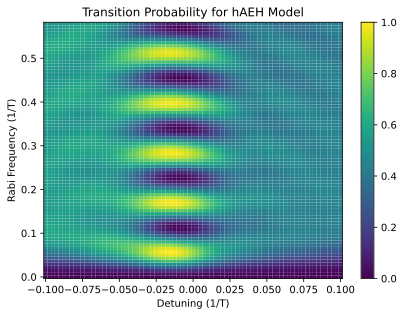

In [9]:
d_range = np.linspace(-d_haeh_max, d_haeh_max, d_num)
A_haeh_range = np.linspace(A_min, A_haeh_max, A_num)
tr_probs_haeh = np.array([[np.abs(r[1,1]) for r in res] for res in result_haeh])[::-1]

# Create pcolormesh plot
fig, ax = plt.subplots(1,1, figsize=(6, 4.5))
cmap = matplotlib.colormaps["viridis"]  # Choose a colormap
im = ax.pcolormesh(d_range, A_haeh_range, tr_probs_haeh.T, vmin=0, vmax=1, shading='auto', cmap="viridis")
fig.colorbar(im, ax=ax)
plt.ylabel('Rabi Frequency (1/T)')
plt.xlabel('Detuning (1/T)')
plt.title('Transition Probability for hAEH Model')
plt.tight_layout()
plt.show()

In [10]:
import os
import pickle
from datetime import datetime
specific_name = "qiskit_experiments"

dt = datetime.now()
date_str = dt.strftime("%Y-%m-%d")
time_str = dt.strftime("%H%M%S")

folder = f"C:/Users/Ivo/Documents/{specific_name}/sims/time_dep/"
save_folder = f"{folder}/lz1_pulses/{date_str}/{time_str}"
os.makedirs(save_folder, exist_ok=True)
with open(os.path.join(save_folder, "tr_prob.pkl"), "wb") as f1:
    pickle.dump(tr_probs_lmsz, f1)
with open(os.path.join(save_folder, "detunings.pkl"), "wb") as f1:
    pickle.dump(np.linspace(-d_lmsz_max, d_lmsz_max, d_num), f1)
with open(os.path.join(save_folder, "areas.pkl"), "wb") as f1:
    pickle.dump(A_lmsz_range, f1)


In [11]:
import os
import pickle
specific_name = "qiskit_experiments"
folder = f"C:/Users/Ivo/Documents/{specific_name}/sims/time_dep/"
save_folder = f"{folder}/ae8_pulses/{date_str}/{time_str}"
os.makedirs(save_folder, exist_ok=True)
with open(os.path.join(save_folder, "tr_prob.pkl"), "wb") as f1:
    pickle.dump(tr_probs_aeh, f1)
with open(os.path.join(save_folder, "detunings.pkl"), "wb") as f1:
    pickle.dump(np.linspace(-d_aeh_max, d_aeh_max, d_num), f1)
with open(os.path.join(save_folder, "areas.pkl"), "wb") as f1:
    pickle.dump(A_aeh_range, f1)


In [12]:
import os
import pickle
specific_name = "qiskit_experiments"
folder = f"C:/Users/Ivo/Documents/{specific_name}/sims/time_dep/"
save_folder = f"{folder}/hae8_pulses/{date_str}/{time_str}"
os.makedirs(save_folder, exist_ok=True)
with open(os.path.join(save_folder, "tr_prob.pkl"), "wb") as f1:
    pickle.dump(tr_probs_haeh, f1)
with open(os.path.join(save_folder, "detunings.pkl"), "wb") as f1:
    pickle.dump(np.linspace(-d_haeh_max, d_haeh_max, d_num), f1)
with open(os.path.join(save_folder, "areas.pkl"), "wb") as f1:
    pickle.dump(A_haeh_range, f1)


In [ ]:
import numpy as np
import scqubits
from scipy.optimize import minimize
twopi = 2 * np.pi

In [ ]:
# Define the objective function to be optimized
def objective_function(params):
    transmon = scqubits.Transmon(EJ=params[0],
                                 EC=params[1],
                                 ng=0,
                                 ncut=31,
                                 truncated_dim=8)
    exc_energies = np.diff(transmon.eigenvals())
    anharm = np.diff(exc_energies)[0]
    return (exc_energies[0] - obj_energy)**2 + (anharm - obj_anharm)**2


In [ ]:
initial_guess = [10, 0.2]
obj_energy, obj_anharm = 4.6040 * twopi, -0.3075 * twopi
bounds = [(0, 100), (0, 100)]
result = minimize(objective_function, initial_guess, bounds=bounds)
# Print the optimization result
print("Optimization Result:")
print("Success:", result.success)
print("Message:", result.message)
print("Optimal Parameters:", result.x)
print("Objective Function Value at Optimum:", result.fun)

In [ ]:
transmon = scqubits.Transmon(
    
    EJ=71.10953541,  
    EC=1.65550678,
    ng=0,
    ncut=31,
    truncated_dim=8)    
exc_energies = np.diff(transmon.eigenvals())
anharm = np.diff(exc_energies)[0]
print(transmon.eigenvals())
print(exc_energies/(2*np.pi))
print(transmon.n_operator(True))
ham = np.diff(np.diag(transmon.hamiltonian(True))) + np.ones(7) * -5
ham = np.diag(np.insert(ham, 0, [0]))
print(ham)

In [ ]:
transmon = scqubits.Transmon(
    EJ=71.10953541,  
    EC=1.65550678,
    ng=0,
    ncut=31,
    truncated_dim=8
)    

H0 = np.insert(np.diff(np.diag(transmon.hamiltonian(True))) - obj_energy, 0, [0])
H0 = np.diag(H0)
#     H0 += np.diag(np.ones(8) * args["d"])

print(H0)

H1 = transmon.n_operator(True)
H1 /= H1[0,1]
H1 /= 2

print(H1)
# H2 = np.diag(np.ones(8))
H2 = np.diag(np.arange(8))
# H2[0,0] = 0
print(H2)

# H = [qutip.Qobj(H0), [qutip.Qobj(H1), pulse_func], [qutip.Qobj(H2), delta_func]]

# print(H)

In [ ]:
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

# Define transmon parameters
Ej = 13.30993317  # Josephson energy in GHz
Ec = 0.26147263   # Charging energy in GHz
ng = 0.0          # Offset charge
ncut = 31         # Charge basis truncation
trunc = 8         # Truncation of the transmon Hilbert space

# Create Transmon object
transmon = scq.Transmon(EJ=Ej, EC=Ec, ng=ng, ncut=ncut, truncated_dim=trunc)

# Calculate the eigenvalues (energy levels) and eigenvectors of the transmon Hamiltonian
evals, evecs = transmon.eigensys()

# Construct the Hamiltonian in the energy basis (diagonal matrix with eigenvalues)
H_energy_basis = np.diag(evals)

# Print the Hamiltonian in the energy basis
print("Hamiltonian in the energy basis (diagonal elements):")
for idx, energy in enumerate(np.diag(H_energy_basis)):
    print(f"Level {idx}: {energy:.4f} GHz")

# Verify if the diagonal elements are positive
are_positive = np.all(np.diag(H_energy_basis) > 0)
print(f"\nAll diagonal elements positive: {are_positive}")
print(f"\nAll diagonal elements positive: {np.diag(H_energy_basis)}")

# Plot the Hamiltonian diagonal elements
plt.plot(np.diag(H_energy_basis), 'o-')
plt.xlabel("State index")
plt.ylabel("Energy (GHz)")
plt.title("Hamiltonian in the Energy Basis (Diagonal Elements)")
plt.grid(True)
plt.show()